# Validação Paralela de Clusters em GPU
## Aceleração CUDA *matrix-free* das métricas de Dunn, Silhueta e Davies-Bouldin

**Equipe:** Henrique M. M. Miranda (202405479) · Cindy Stephanie Gomes Rabelo (202403898) · Luiany Goncalves Carvalho (202303351)

**Disciplina:** Computação de Alto Desempenho — **Prof.:** Ricardo Augusto Pereira Franco — UFG / Instituto de Informática

**Repositório:** https://github.com/Ricktheus/Trabalho-final-Cuda

---

### Resumo
A validação interna de agrupamentos (Dunn, Silhueta, Davies-Bouldin) exige distâncias euclidianas par-a-par entre todos os pontos — custo de tempo **O(N²)**, proibitivo em CPU sequencial. Implementamos os três índices em **GPU/CUDA** de forma **exata** com uma estratégia **matrix-free** que **não materializa** a matriz N×N (distâncias recomputadas sob demanda nos kernels), reduzindo a memória de **O(N²)** para **O(N·D)** e viabilizando **N=100.000** pontos. Contra um baseline em CPU (sequencial e OpenMP) na mesma máquina, obtivemos **speed-up de até 24,9×** (vs. CPU sequencial) e **24,5×** (vs. CPU OpenMP), com corretude validada em três camadas (caso analítico, scikit-learn e equivalência CPU≡GPU).

## ▶️ Como executar este notebook

1. Abra no **Google Colab**.
2. Menu **Ambiente de execução → Alterar o tipo de ambiente de execução → Acelerador de hardware: GPU (T4)**.
3. **Ambiente de execução → Executar tudo** (`Ctrl+F9`).

> O notebook escreve o código-fonte, compila CPU (`g++ -fopenmp`) e GPU (`nvcc`), valida a corretude e roda o benchmark até **N=100.000** (≈ 8–10 min). Para um teste rápido (< 1 min), troque a célula de execução por `!python benchmark.py --max 8000`.

A seção seguinte mostra os **resultados de referência já obtidos** — útil para leitura sem executar.

## 📊 Resultados de referência (NVIDIA Tesla T4 — Google Colab)

| N | CPU-1 (s) | CPU-OMP (s) | GPU (s) | SU vs CPU-1 | SU vs OpenMP | Corretude |
|---:|---:|---:|---:|---:|---:|:---:|
| 250 | 0.0018 | 0.0077 | 0.0011 | 1.6× | 6.8× | 100% |
| 500 | 0.0029 | 0.0029 | 0.0021 | 1.4× | 1.4× | 100% |
| 1.000 | 0.0090 | 0.0087 | 0.0026 | 3.4× | 3.3× | 100% |
| 2.000 | 0.0365 | 0.0326 | 0.0055 | 6.6× | 5.9× | 100% |
| 4.000 | 0.1215 | 0.1150 | 0.0124 | 9.8× | 9.3× | 100% |
| 8.000 | 0.6943 | 0.4576 | 0.0426 | 16.3× | 10.7× | 100% |
| 16.000 | 2.2145 | 1.8804 | 0.1232 | 18.0× | 15.3× | 100% |
| 32.000 | 8.2827 | 8.1136 | 0.4033 | 20.5× | 20.1× | 100% |
| 50.000 | 20.4357 | 19.4384 | 0.9273 | 22.0× | 21.0× | 100% |
| 100.000 | 80.6082 | 79.2305 | 3.2354 | 24.9× | 24.5× | 100% |

- **Speed-up máximo:** 24,9× vs. CPU-1thread e 24,5× vs. CPU-OpenMP em N=100.000.
- **Corretude:** 100% CPU≡GPU em todos os tamanhos; erro ~10⁻⁹ vs. scikit-learn; caso analítico do Dunn = 2,000000 (erro 0).


### Figuras geradas pelo `benchmark.py` (T4 no Colab)

**Figura 1 — Tempo de execução vs. N** (linear e log-log):

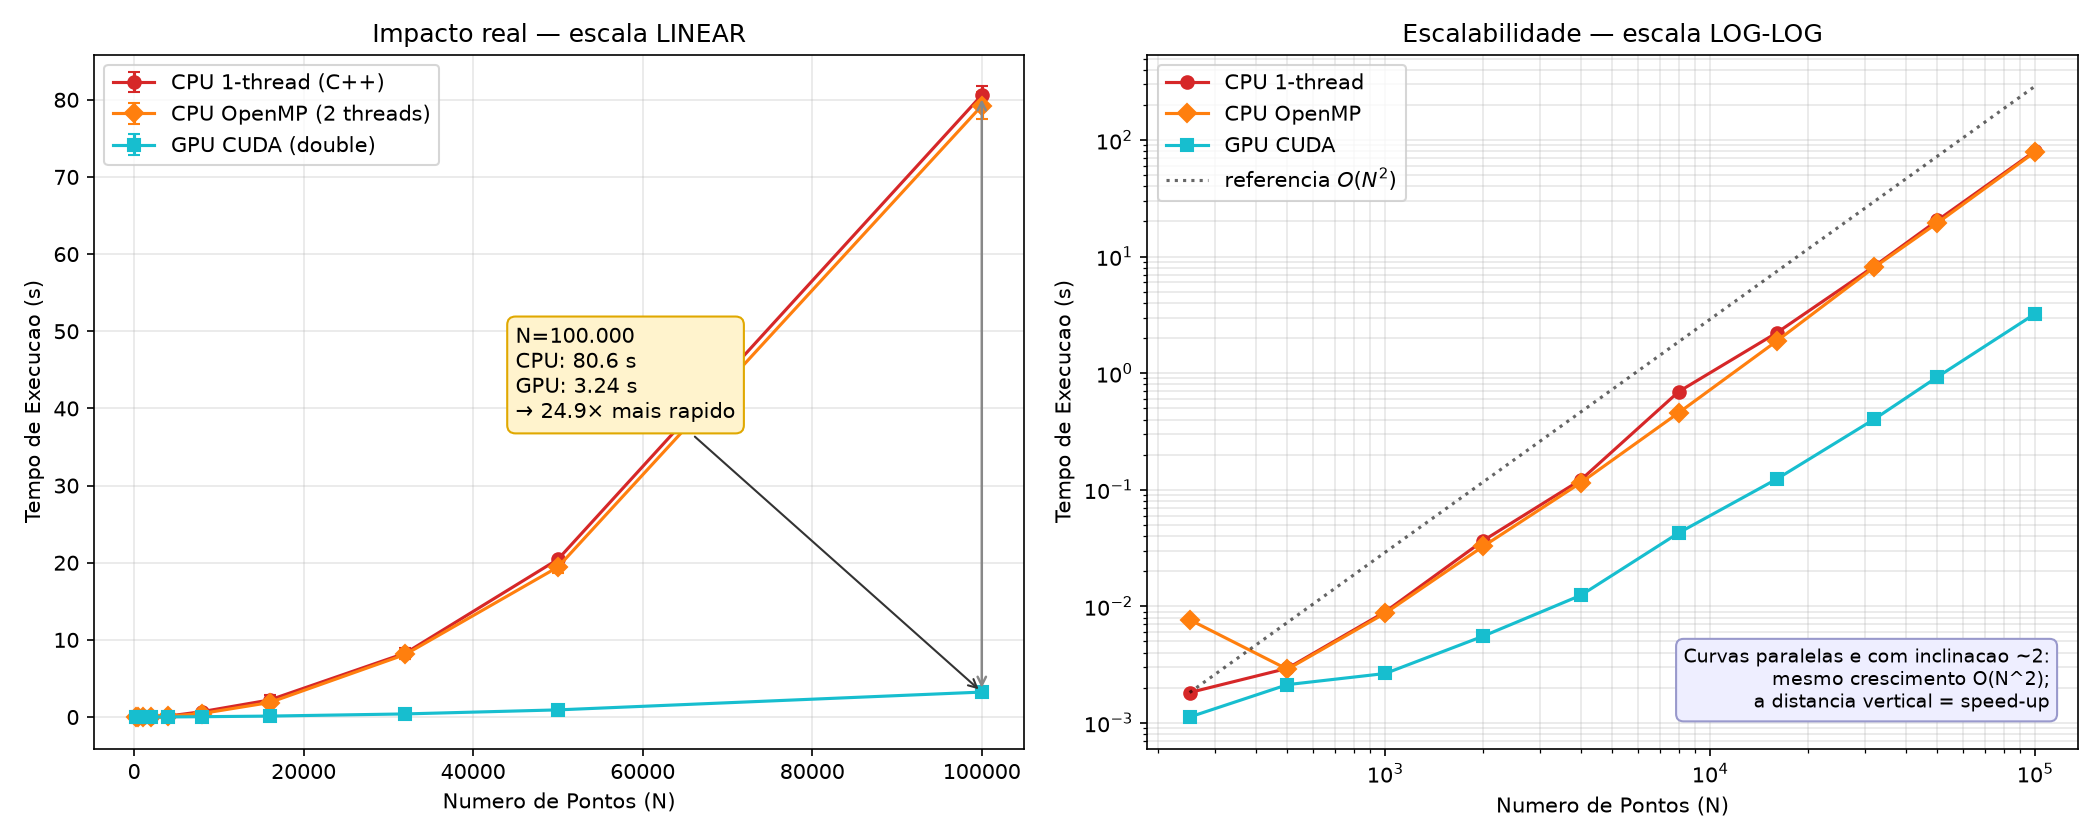

**Figura 2 — Speed-up vs. N** (GPU vs CPU-1thread e vs CPU-OpenMP):

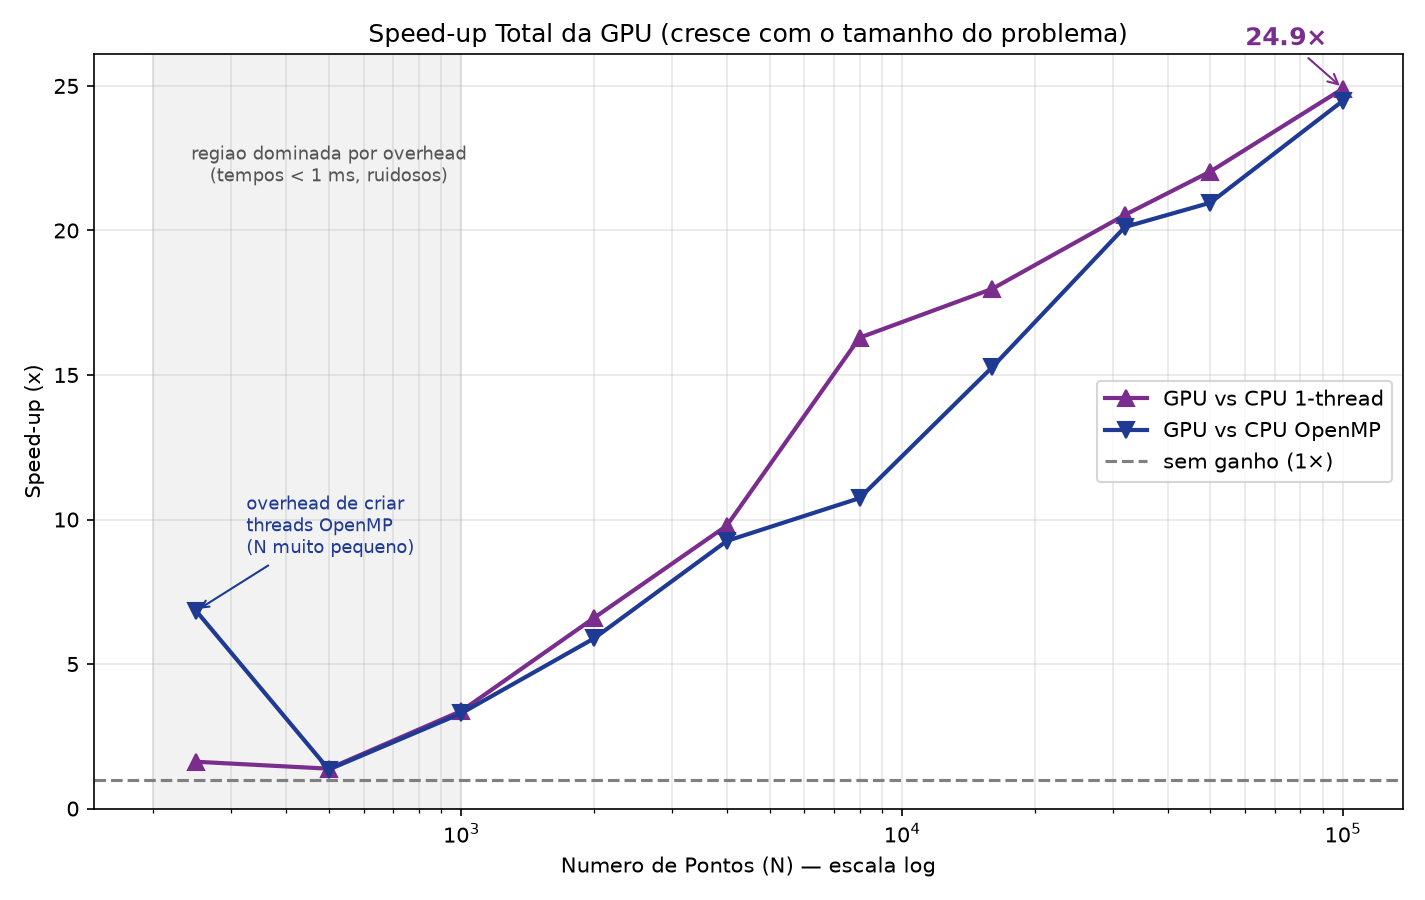

**Figura 3 — Breakdown do tempo de GPU por etapa.** *Obs.: as porcentagens são fração das 4 etapas medidas (H2D, Dunn, Silhueta, DB); o `GPU (s)` da tabela inclui ainda a leitura do dataset no host (~0,12 s em N=100k), que não é etapa de GPU.*

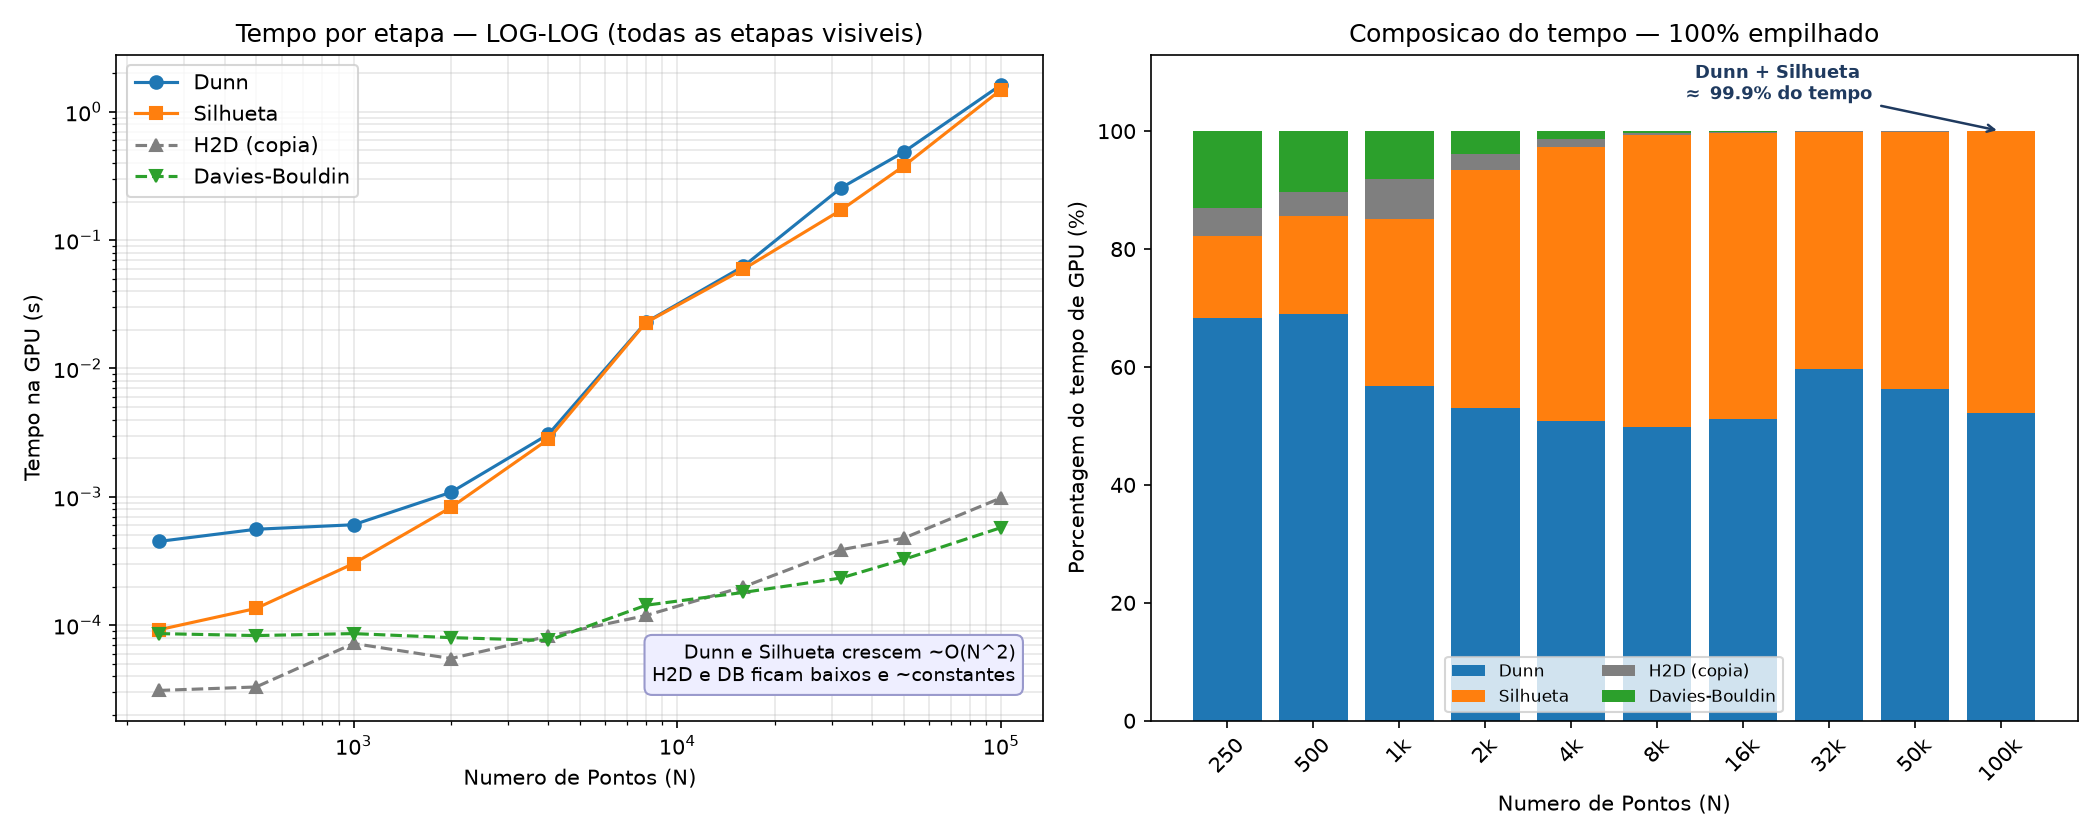


---
## 🔁 Reprodução

### 0. Ambiente

In [ ]:
# Verifica a GPU disponível (precisa do runtime com GPU ativado)
!nvidia-smi

In [ ]:
# Dependências (já presentes no Colab, mas garantimos as versões)
!pip -q install numpy scikit-learn matplotlib pandas

### 1. `metrics_cuda.cu` — kernels CUDA (Dunn, Silhueta, Davies-Bouldin)

In [ ]:
%%writefile metrics_cuda.cu
// ======================================================================
//  metrics_cuda.cu  -  Versao MATRIX-FREE (sem materializar a matriz NxN)
// ----------------------------------------------------------------------
//  Calculo paralelo em GPU (CUDA) de tres metricas de validacao de
//  clusters: Indice de Dunn, Coeficiente de Silhueta e Davies-Bouldin.
//
//  Diferenca para a versao anterior:
//    - NAO alocamos mais a matriz de distancias D[N*N] na VRAM.
//    - As distancias par-a-par sao recalculadas "on-the-fly" dentro dos
//      kernels de Dunn e Silhueta (cada bloco trata uma linha/ponto i e
//      varre os demais pontos j calculando d(i,j) a partir de X).
//    - Memoria passa de O(N^2) para O(N*D): viabiliza N=50.000/100.000.
//    - Remove o overflow de int em (N*N) que ocorria para N grande.
//
//  Precisao (trade-off velocidade x exatidao):
//    - Compile com  -DUSE_FLOAT  para usar float nas coordenadas e no
//      calculo das distancias (mais rapido na T4, que e fraca em fp64).
//    - Sem a flag, usa double (padrao, validado contra a CPU/sklearn).
//    - As reducoes/somatorios acumulam sempre em double para preservar
//      a exatidao mesmo no modo float.
// ======================================================================

#include <iostream>
#include <vector>
#include <cmath>
#include <string>
#include <fstream>
#include <sstream>
#include <algorithm>
#include <iomanip>
#include <limits>
#include <chrono>
#include <set>
#include <cuda_runtime.h>

// ----------------------------------------------------------------------
// Tipo de precisao para coordenadas e distancias (float opcional)
// ----------------------------------------------------------------------
#ifdef USE_FLOAT
  typedef float real_t;
  #define DEV_SQRT(x) sqrtf(x)
  #define PRECISION_LABEL 0
#else
  typedef double real_t;
  #define DEV_SQRT(x) sqrt(x)
  #define PRECISION_LABEL 1
#endif

#define MAX_D 128          // dimensao maxima suportada (cabe em shared estatica)
#define BLOCK_SIZE 256     // threads por bloco (potencia de 2 p/ reducao)

// Estrutura para armazenar o dataset na CPU
struct Dataset {
    int N;
    int D;
    int K;
    std::vector<real_t> X;
    std::vector<int> labels;
    std::vector<int> unique_labels;
};

// Carrega o dataset (mesmo formato do baseline CPU: "N D K" + N linhas)
Dataset load_dataset(const std::string& filepath) {
    Dataset ds;
    std::ifstream file(filepath);
    if (!file.is_open()) {
        std::cerr << "Erro ao abrir o arquivo: " << filepath << std::endl;
        std::exit(1);
    }

    std::string line;
    if (std::getline(file, line)) {
        std::stringstream ss(line);
        ss >> ds.N >> ds.D >> ds.K;
    }

    ds.X.resize((size_t)ds.N * ds.D);
    ds.labels.resize(ds.N);

    std::set<int> label_set;
    for (int i = 0; i < ds.N; ++i) {
        if (!std::getline(file, line)) {
            std::cerr << "Erro de leitura na linha " << i + 2 << std::endl;
            std::exit(1);
        }
        std::stringstream ss(line);
        double v;
        for (int d = 0; d < ds.D; ++d) {
            ss >> v;
            ds.X[(size_t)i * ds.D + d] = (real_t)v;
        }
        ss >> ds.labels[i];
        label_set.insert(ds.labels[i]);
    }

    ds.unique_labels.assign(label_set.begin(), label_set.end());
    for (int i = 0; i < ds.N; ++i) {
        auto it = std::find(ds.unique_labels.begin(), ds.unique_labels.end(), ds.labels[i]);
        ds.labels[i] = std::distance(ds.unique_labels.begin(), it);
    }

    return ds;
}

// Macro para tratar erros de CUDA
#define CUDA_CHECK(call) \
    do { \
        cudaError_t err = call; \
        if (err != cudaSuccess) { \
            std::cerr << "CUDA Error at " << __FILE__ << ":" << __LINE__ \
                      << " - " << cudaGetErrorString(err) << std::endl; \
            std::exit(1); \
        } \
    } while (0)

// ----------------------------------------------------------------------
// Suporte a atomicAdd para double em arquiteturas antigas (< sm_60)
// ----------------------------------------------------------------------
#if !defined(__CUDA_ARCH__) || __CUDA_ARCH__ < 600
#if defined(__CUDA_ARCH__)
__device__ double atomicAdd(double* address, double val) {
    unsigned long long int* address_as_ull = (unsigned long long int*)address;
    unsigned long long int old = *address_as_ull, assumed;
    do {
        assumed = old;
        old = atomicCAS(address_as_ull, assumed,
                        __double_as_longlong(val + __longlong_as_double(assumed)));
    } while (assumed != old);
    return __longlong_as_double(old);
}
#endif
#endif

// Distancia euclidiana on-the-fly entre o ponto i (em shared) e o ponto j (global).
// O somatorio e feito em real_t (rapido em float); o resultado retorna em double.
__device__ __forceinline__ double dev_dist(const real_t* xi, const real_t* X, int j, int D) {
    real_t sum = (real_t)0;
    const real_t* xj = X + (size_t)j * D;
    #pragma unroll 4
    for (int d = 0; d < D; ++d) {
        real_t diff = xi[d] - xj[d];
        sum += diff * diff;
    }
    return (double)DEV_SQRT(sum);
}

// ----------------------------------------------------------------------
// KERNELS CUDA (MATRIX-FREE)
// ----------------------------------------------------------------------

// 1. Indice de Dunn — um bloco por linha i; distancias calculadas on-the-fly.
//    Cada bloco encontra o maior intra-cluster e o menor inter-cluster da linha.
__global__ void dunn_rowwise_kernel(const real_t* X, const int* labels,
                                    double* row_max_intra, double* row_min_inter,
                                    int N, int D) {
    int i = blockIdx.x;            // um bloco por ponto/linha
    int tx = threadIdx.x;

    __shared__ real_t s_xi[MAX_D]; // coordenadas do ponto i (reuso por todas as threads)
    __shared__ double s_max[BLOCK_SIZE];
    __shared__ double s_min[BLOCK_SIZE];

    for (int d = tx; d < D; d += blockDim.x) s_xi[d] = X[(size_t)i * D + d];
    __syncthreads();

    double local_max = 0.0;
    double local_min = 1e18;       // "infinito"
    int own_label = labels[i];

    for (int j = tx; j < N; j += blockDim.x) {
        if (j == i) continue;
        double dist = dev_dist(s_xi, X, j, D);
        if (labels[j] == own_label) {
            if (dist > local_max) local_max = dist;
        } else {
            if (dist < local_min) local_min = dist;
        }
    }

    s_max[tx] = local_max;
    s_min[tx] = local_min;
    __syncthreads();

    // Reducao em arvore em memoria compartilhada
    for (int stride = blockDim.x / 2; stride > 0; stride /= 2) {
        if (tx < stride) {
            if (s_max[tx + stride] > s_max[tx]) s_max[tx] = s_max[tx + stride];
            if (s_min[tx + stride] < s_min[tx]) s_min[tx] = s_min[tx + stride];
        }
        __syncthreads();
    }

    if (tx == 0) {
        row_max_intra[i] = s_max[0];
        row_min_inter[i] = s_min[0];
    }
}

// 2. Coeficiente de Silhueta — um bloco por ponto i; distancias on-the-fly.
//    shared_sums (dinamica) acumula em double a soma de d(i,j) por cluster.
__global__ void silhouette_rowwise_kernel(const real_t* X, const int* labels,
                                          const int* cluster_sizes, double* s,
                                          int N, int K, int D) {
    int i = blockIdx.x;
    int tx = threadIdx.x;

    extern __shared__ double shared_sums[]; // tamanho: blockDim.x * K
    __shared__ real_t s_xi[MAX_D];

    for (int d = tx; d < D; d += blockDim.x) s_xi[d] = X[(size_t)i * D + d];
    for (int c = 0; c < K; ++c) shared_sums[tx * K + c] = 0.0;
    __syncthreads();

    int own_cluster = labels[i];

    for (int j = tx; j < N; j += blockDim.x) {
        if (j == i) continue;
        int c_j = labels[j];
        if (c_j >= 0 && c_j < K) {
            shared_sums[tx * K + c_j] += dev_dist(s_xi, X, j, D);
        }
    }
    __syncthreads();

    // Reducao entre as threads do bloco para cada um dos K clusters
    if (tx < K) {
        double total_sum = 0.0;
        for (int t = 0; t < blockDim.x; ++t) {
            total_sum += shared_sums[t * K + tx];
        }
        shared_sums[tx] = total_sum; // reutiliza as K primeiras posicoes
    }
    __syncthreads();

    if (tx == 0) {
        if (cluster_sizes[own_cluster] <= 1) {
            s[i] = 0.0;
        } else {
            double a = shared_sums[own_cluster] / (cluster_sizes[own_cluster] - 1);
            double b = 1e18;
            for (int c = 0; c < K; ++c) {
                if (c == own_cluster) continue;
                if (cluster_sizes[c] == 0) continue;
                double avg_dist = shared_sums[c] / cluster_sizes[c];
                if (avg_dist < b) b = avg_dist;
            }
            s[i] = (b - a) / fmax(a, b);
        }
    }
}

// 3. Davies-Bouldin (ja era matrix-free: baseado em centroides)
__global__ void compute_centroids_kernel(const real_t* X, const int* labels,
                                         double* centroids, int* cluster_sizes, int N, int D) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) {
        int c = labels[i];
        for (int d = 0; d < D; ++d) {
            atomicAdd(&centroids[c * D + d], (double)X[(size_t)i * D + d]);
        }
        atomicAdd(&cluster_sizes[c], 1);
    }
}

__global__ void divide_centroids_kernel(double* centroids, const int* cluster_sizes, int K, int D) {
    int c = blockIdx.x * blockDim.x + threadIdx.x;
    if (c < K) {
        int size = cluster_sizes[c];
        if (size > 0) {
            for (int d = 0; d < D; ++d) centroids[c * D + d] /= size;
        }
    }
}

__global__ void compute_dispersion_kernel(const real_t* X, const int* labels,
                                          const double* centroids, double* S, int N, int D) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) {
        int c = labels[i];
        double sum_sq = 0.0;
        for (int d = 0; d < D; ++d) {
            double diff = (double)X[(size_t)i * D + d] - centroids[c * D + d];
            sum_sq += diff * diff;
        }
        atomicAdd(&S[c], sqrt(sum_sq));
    }
}

__global__ void divide_dispersion_kernel(double* S, const int* cluster_sizes, int K) {
    int c = blockIdx.x * blockDim.x + threadIdx.x;
    if (c < K) {
        int size = cluster_sizes[c];
        if (size > 0) S[c] /= size;
    }
}

__global__ void compute_db_kernel(const double* S, const double* centroids,
                                  double* db_ratios, int K, int D) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < K) {
        double max_ratio = 0.0;
        for (int j = 0; j < K; ++j) {
            if (i == j) continue;
            double sum_sq = 0.0;
            for (int d = 0; d < D; ++d) {
                double diff = centroids[i * D + d] - centroids[j * D + d];
                sum_sq += diff * diff;
            }
            double M_ij = sqrt(sum_sq);
            if (M_ij > 0.0) {
                double ratio = (S[i] + S[j]) / M_ij;
                if (ratio > max_ratio) max_ratio = ratio;
            }
        }
        db_ratios[i] = max_ratio;
    }
}

// ----------------------------------------------------------------------
// MAIN
// ----------------------------------------------------------------------
int main(int argc, char* argv[]) {
    if (argc < 2) {
        std::cerr << "Uso: " << argv[0] << " <caminho_do_dataset.csv> [apenas_dunn: 0 ou 1]" << std::endl;
        return 1;
    }

    std::string filepath = argv[1];
    bool run_all = true;
    if (argc >= 3) run_all = (std::stoi(argv[2]) == 0);

    // 1. Carrega o dataset na CPU
    auto t_load_start = std::chrono::high_resolution_clock::now();
    Dataset ds = load_dataset(filepath);
    auto t_load_end = std::chrono::high_resolution_clock::now();
    double cpu_load_time = std::chrono::duration<double>(t_load_end - t_load_start).count();

    if (ds.D > MAX_D) {
        std::cerr << "Erro: D=" << ds.D << " excede MAX_D=" << MAX_D << std::endl;
        return 1;
    }

    // 2. Alocacao e copia Host -> Device (apenas X e labels: O(N*D), nao mais O(N^2))
    real_t* d_X;
    int* d_labels;
    CUDA_CHECK(cudaMalloc(&d_X, (size_t)ds.N * ds.D * sizeof(real_t)));
    CUDA_CHECK(cudaMalloc(&d_labels, (size_t)ds.N * sizeof(int)));

    auto t_h2d_start = std::chrono::high_resolution_clock::now();
    CUDA_CHECK(cudaMemcpy(d_X, ds.X.data(), (size_t)ds.N * ds.D * sizeof(real_t), cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_labels, ds.labels.data(), (size_t)ds.N * sizeof(int), cudaMemcpyHostToDevice));
    auto t_h2d_end = std::chrono::high_resolution_clock::now();
    double h2d_time = std::chrono::duration<double>(t_h2d_end - t_h2d_start).count();

    cudaEvent_t start, stop;
    CUDA_CHECK(cudaEventCreate(&start));
    CUDA_CHECK(cudaEventCreate(&stop));

    // ------------------------------------------------------------------
    // A. Indice de Dunn (distancias on-the-fly)
    // ------------------------------------------------------------------
    double* d_row_max;
    double* d_row_min;
    CUDA_CHECK(cudaMalloc(&d_row_max, (size_t)ds.N * sizeof(double)));
    CUDA_CHECK(cudaMalloc(&d_row_min, (size_t)ds.N * sizeof(double)));

    CUDA_CHECK(cudaEventRecord(start));
    dunn_rowwise_kernel<<<ds.N, BLOCK_SIZE>>>(d_X, d_labels, d_row_max, d_row_min, ds.N, ds.D);
    CUDA_CHECK(cudaEventRecord(stop));
    CUDA_CHECK(cudaEventSynchronize(stop));

    float dunn_ms = 0.0f;
    CUDA_CHECK(cudaEventElapsedTime(&dunn_ms, start, stop));

    std::vector<double> h_row_max(ds.N), h_row_min(ds.N);
    CUDA_CHECK(cudaMemcpy(h_row_max.data(), d_row_max, ds.N * sizeof(double), cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(h_row_min.data(), d_row_min, ds.N * sizeof(double), cudaMemcpyDeviceToHost));

    double max_intra = 0.0;
    double min_inter = std::numeric_limits<double>::infinity();
    for (int i = 0; i < ds.N; ++i) {
        if (h_row_max[i] > max_intra) max_intra = h_row_max[i];
        if (h_row_min[i] < min_inter) min_inter = h_row_min[i];
    }
    double dunn_score = (max_intra == 0.0) ? 0.0 : (min_inter / max_intra);
    double dunn_time = dunn_ms / 1000.0;

    CUDA_CHECK(cudaFree(d_row_max));
    CUDA_CHECK(cudaFree(d_row_min));

    // ------------------------------------------------------------------
    // B. Coeficiente de Silhueta (distancias on-the-fly)
    // ------------------------------------------------------------------
    double sil_score = -2.0;
    double sil_time = 0.0;

    if (run_all) {
        std::vector<int> h_cluster_sizes(ds.K, 0);
        for (int i = 0; i < ds.N; ++i) h_cluster_sizes[ds.labels[i]]++;

        int* d_cluster_sizes;
        double* d_s;
        CUDA_CHECK(cudaMalloc(&d_cluster_sizes, ds.K * sizeof(int)));
        CUDA_CHECK(cudaMalloc(&d_s, (size_t)ds.N * sizeof(double)));
        CUDA_CHECK(cudaMemcpy(d_cluster_sizes, h_cluster_sizes.data(), ds.K * sizeof(int), cudaMemcpyHostToDevice));

        size_t shared_mem_size = (size_t)BLOCK_SIZE * ds.K * sizeof(double);

        CUDA_CHECK(cudaEventRecord(start));
        silhouette_rowwise_kernel<<<ds.N, BLOCK_SIZE, shared_mem_size>>>(d_X, d_labels, d_cluster_sizes, d_s, ds.N, ds.K, ds.D);
        CUDA_CHECK(cudaEventRecord(stop));
        CUDA_CHECK(cudaEventSynchronize(stop));

        float sil_ms = 0.0f;
        CUDA_CHECK(cudaEventElapsedTime(&sil_ms, start, stop));

        std::vector<double> h_s(ds.N);
        CUDA_CHECK(cudaMemcpy(h_s.data(), d_s, ds.N * sizeof(double), cudaMemcpyDeviceToHost));

        double sil_sum = 0.0;
        for (int i = 0; i < ds.N; ++i) sil_sum += h_s[i];
        sil_score = sil_sum / ds.N;
        sil_time = sil_ms / 1000.0;

        CUDA_CHECK(cudaFree(d_cluster_sizes));
        CUDA_CHECK(cudaFree(d_s));
    }

    // ------------------------------------------------------------------
    // C. Davies-Bouldin
    // ------------------------------------------------------------------
    double db_score = -1.0;
    double db_time = 0.0;

    if (run_all) {
        double* d_centroids;
        int* d_db_cluster_sizes;
        double* d_S;
        double* d_db_ratios;

        CUDA_CHECK(cudaMalloc(&d_centroids, (size_t)ds.K * ds.D * sizeof(double)));
        CUDA_CHECK(cudaMalloc(&d_db_cluster_sizes, ds.K * sizeof(int)));
        CUDA_CHECK(cudaMalloc(&d_S, ds.K * sizeof(double)));
        CUDA_CHECK(cudaMalloc(&d_db_ratios, ds.K * sizeof(double)));

        CUDA_CHECK(cudaMemset(d_centroids, 0, (size_t)ds.K * ds.D * sizeof(double)));
        CUDA_CHECK(cudaMemset(d_db_cluster_sizes, 0, ds.K * sizeof(int)));
        CUDA_CHECK(cudaMemset(d_S, 0, ds.K * sizeof(double)));

        int blocksForPoints = (ds.N + BLOCK_SIZE - 1) / BLOCK_SIZE;
        int blocksForClusters = (ds.K + BLOCK_SIZE - 1) / BLOCK_SIZE;

        CUDA_CHECK(cudaEventRecord(start));
        compute_centroids_kernel<<<blocksForPoints, BLOCK_SIZE>>>(d_X, d_labels, d_centroids, d_db_cluster_sizes, ds.N, ds.D);
        divide_centroids_kernel<<<blocksForClusters, BLOCK_SIZE>>>(d_centroids, d_db_cluster_sizes, ds.K, ds.D);
        compute_dispersion_kernel<<<blocksForPoints, BLOCK_SIZE>>>(d_X, d_labels, d_centroids, d_S, ds.N, ds.D);
        divide_dispersion_kernel<<<blocksForClusters, BLOCK_SIZE>>>(d_S, d_db_cluster_sizes, ds.K);
        compute_db_kernel<<<blocksForClusters, BLOCK_SIZE>>>(d_S, d_centroids, d_db_ratios, ds.K, ds.D);
        CUDA_CHECK(cudaEventRecord(stop));
        CUDA_CHECK(cudaEventSynchronize(stop));

        float db_ms = 0.0f;
        CUDA_CHECK(cudaEventElapsedTime(&db_ms, start, stop));

        std::vector<double> h_db_ratios(ds.K);
        CUDA_CHECK(cudaMemcpy(h_db_ratios.data(), d_db_ratios, ds.K * sizeof(double), cudaMemcpyDeviceToHost));

        double db_sum = 0.0;
        for (int i = 0; i < ds.K; ++i) db_sum += h_db_ratios[i];
        db_score = db_sum / ds.K;
        db_time = db_ms / 1000.0;

        CUDA_CHECK(cudaFree(d_centroids));
        CUDA_CHECK(cudaFree(d_db_cluster_sizes));
        CUDA_CHECK(cudaFree(d_S));
        CUDA_CHECK(cudaFree(d_db_ratios));
    }

    CUDA_CHECK(cudaFree(d_X));
    CUDA_CHECK(cudaFree(d_labels));
    CUDA_CHECK(cudaEventDestroy(start));
    CUDA_CHECK(cudaEventDestroy(stop));

    // Saida formatada para o script Python
    std::cout << std::fixed << std::setprecision(8);
    std::cout << "--- RESULTS ---" << std::endl;
    std::cout << "N: " << ds.N << std::endl;
    std::cout << "D: " << ds.D << std::endl;
    std::cout << "K: " << ds.K << std::endl;
    std::cout << "Precision: " << PRECISION_LABEL << std::endl;  // 1=double, 0=float
    std::cout << "Dunn: " << dunn_score << std::endl;
    std::cout << "Silhouette: " << sil_score << std::endl;
    std::cout << "DB: " << db_score << std::endl;
    std::cout << "Time_Load: " << cpu_load_time << std::endl;
    std::cout << "Time_H2D: " << h2d_time << std::endl;
    std::cout << "Time_Dunn: " << dunn_time << std::endl;
    std::cout << "Time_Silhouette: " << sil_time << std::endl;
    std::cout << "Time_DB: " << db_time << std::endl;
    std::cout << "Time_Total: " << (cpu_load_time + h2d_time + dunn_time + sil_time + db_time) << std::endl;

    return 0;
}


### 2. `baseline_cpu.cpp` — baseline em CPU (sequencial + OpenMP)

In [ ]:
%%writefile baseline_cpu.cpp
// ======================================================================
//  baseline_cpu.cpp  -  Versao MATRIX-FREE (sem materializar a matriz NxN)
// ----------------------------------------------------------------------
//  Baseline sequencial/paralelo (CPU) das tres metricas de validacao de
//  clusters: Indice de Dunn, Coeficiente de Silhueta e Davies-Bouldin.
//
//  Mudancas em relacao a versao anterior:
//    - NAO aloca mais a matriz de distancias D[N*N] (eram 80 GB em N=100k
//      e havia overflow de int em N*N). As distancias sao recalculadas
//      on-the-fly -> memoria O(N*D), viabiliza N=50.000/100.000.
//    - Paralelizacao opcional com OpenMP (compile com -fopenmp). O numero
//      de threads e controlado pela variavel de ambiente OMP_NUM_THREADS,
//      permitindo medir CPU 1-thread vs CPU multi-thread vs GPU.
//
//  Compilacao:
//    g++ -O3 -fopenmp baseline_cpu.cpp -o baseline_cpu     (multi-thread)
//    g++ -O3            baseline_cpu.cpp -o baseline_cpu     (sequencial)
// ======================================================================

#include <iostream>
#include <vector>
#include <cmath>
#include <string>
#include <fstream>
#include <sstream>
#include <algorithm>
#include <iomanip>
#include <limits>
#include <chrono>
#include <set>
#ifdef _OPENMP
#include <omp.h>
#endif

struct Dataset {
    int N;
    int D;
    int K;
    std::vector<double> X;
    std::vector<int> labels;
    std::vector<int> unique_labels;
};

Dataset load_dataset(const std::string& filepath) {
    Dataset ds;
    std::ifstream file(filepath);
    if (!file.is_open()) {
        std::cerr << "Erro ao abrir o arquivo: " << filepath << std::endl;
        std::exit(1);
    }

    std::string line;
    if (std::getline(file, line)) {
        std::stringstream ss(line);
        ss >> ds.N >> ds.D >> ds.K;
    }

    ds.X.resize((size_t)ds.N * ds.D);
    ds.labels.resize(ds.N);

    std::set<int> label_set;
    for (int i = 0; i < ds.N; ++i) {
        if (!std::getline(file, line)) {
            std::cerr << "Erro de leitura na linha " << i + 2 << std::endl;
            std::exit(1);
        }
        std::stringstream ss(line);
        for (int d = 0; d < ds.D; ++d) {
            ss >> ds.X[(size_t)i * ds.D + d];
        }
        ss >> ds.labels[i];
        label_set.insert(ds.labels[i]);
    }

    ds.unique_labels.assign(label_set.begin(), label_set.end());
    for (int i = 0; i < ds.N; ++i) {
        auto it = std::find(ds.unique_labels.begin(), ds.unique_labels.end(), ds.labels[i]);
        ds.labels[i] = std::distance(ds.unique_labels.begin(), it);
    }

    return ds;
}

// Distancia euclidiana on-the-fly entre os pontos i e j
static inline double dist_ij(const Dataset& ds, int i, int j) {
    double sum = 0.0;
    const double* xi = &ds.X[(size_t)i * ds.D];
    const double* xj = &ds.X[(size_t)j * ds.D];
    for (int d = 0; d < ds.D; ++d) {
        double diff = xi[d] - xj[d];
        sum += diff * diff;
    }
    return std::sqrt(sum);
}

// 1) Indice de Dunn (matrix-free)
double compute_dunn_index(const Dataset& ds) {
    double max_intra = 0.0;
    double min_inter = std::numeric_limits<double>::infinity();

    #pragma omp parallel for schedule(dynamic, 64) \
            reduction(max:max_intra) reduction(min:min_inter)
    for (int i = 0; i < ds.N; ++i) {
        int li = ds.labels[i];
        for (int j = i + 1; j < ds.N; ++j) {
            double dist = dist_ij(ds, i, j);
            if (li == ds.labels[j]) {
                if (dist > max_intra) max_intra = dist;
            } else {
                if (dist < min_inter) min_inter = dist;
            }
        }
    }

    if (max_intra == 0.0) return 0.0;
    return min_inter / max_intra;
}

// 2) Coeficiente de Silhueta (matrix-free)
double compute_silhouette_index(const Dataset& ds) {
    std::vector<int> cluster_sizes(ds.K, 0);
    for (int i = 0; i < ds.N; ++i) cluster_sizes[ds.labels[i]]++;

    double silhouette_sum = 0.0;

    #pragma omp parallel for schedule(dynamic, 64) reduction(+:silhouette_sum)
    for (int i = 0; i < ds.N; ++i) {
        int own_cluster = ds.labels[i];
        if (cluster_sizes[own_cluster] <= 1) continue;

        std::vector<double> dist_sum(ds.K, 0.0);
        for (int j = 0; j < ds.N; ++j) {
            if (j == i) continue;
            dist_sum[ds.labels[j]] += dist_ij(ds, i, j);
        }

        double a = dist_sum[own_cluster] / (cluster_sizes[own_cluster] - 1);
        double b = std::numeric_limits<double>::infinity();
        for (int c = 0; c < ds.K; ++c) {
            if (c == own_cluster) continue;
            if (cluster_sizes[c] == 0) continue;
            double avg_dist = dist_sum[c] / cluster_sizes[c];
            if (avg_dist < b) b = avg_dist;
        }
        silhouette_sum += (b - a) / std::max(a, b);
    }

    return silhouette_sum / ds.N;
}

// 3) Indice Davies-Bouldin (baseado em centroides; ja era O(N))
double compute_davies_bouldin_index(const Dataset& ds) {
    std::vector<double> centroids((size_t)ds.K * ds.D, 0.0);
    std::vector<int> cluster_sizes(ds.K, 0);

    for (int i = 0; i < ds.N; ++i) {
        int c = ds.labels[i];
        cluster_sizes[c]++;
        for (int d = 0; d < ds.D; ++d) {
            centroids[(size_t)c * ds.D + d] += ds.X[(size_t)i * ds.D + d];
        }
    }
    for (int c = 0; c < ds.K; ++c) {
        if (cluster_sizes[c] > 0) {
            for (int d = 0; d < ds.D; ++d) centroids[(size_t)c * ds.D + d] /= cluster_sizes[c];
        }
    }

    std::vector<double> S(ds.K, 0.0);
    for (int i = 0; i < ds.N; ++i) {
        int c = ds.labels[i];
        double sum_sq = 0.0;
        for (int d = 0; d < ds.D; ++d) {
            double diff = ds.X[(size_t)i * ds.D + d] - centroids[(size_t)c * ds.D + d];
            sum_sq += diff * diff;
        }
        S[c] += std::sqrt(sum_sq);
    }
    for (int c = 0; c < ds.K; ++c) {
        if (cluster_sizes[c] > 0) S[c] /= cluster_sizes[c];
    }

    double db_sum = 0.0;
    for (int i = 0; i < ds.K; ++i) {
        if (cluster_sizes[i] == 0) continue;
        double max_ratio = 0.0;
        for (int j = 0; j < ds.K; ++j) {
            if (i == j || cluster_sizes[j] == 0) continue;
            double sum_sq = 0.0;
            for (int d = 0; d < ds.D; ++d) {
                double diff = centroids[(size_t)i * ds.D + d] - centroids[(size_t)j * ds.D + d];
                sum_sq += diff * diff;
            }
            double M_ij = std::sqrt(sum_sq);
            if (M_ij > 0.0) {
                double ratio = (S[i] + S[j]) / M_ij;
                if (ratio > max_ratio) max_ratio = ratio;
            }
        }
        db_sum += max_ratio;
    }

    return db_sum / ds.K;
}

int main(int argc, char* argv[]) {
    if (argc < 2) {
        std::cerr << "Uso: " << argv[0] << " <caminho_do_dataset.csv> [apenas_dunn: 0 ou 1]" << std::endl;
        return 1;
    }

    std::string filepath = argv[1];
    bool run_all = true;
    if (argc >= 3) run_all = (std::stoi(argv[2]) == 0);

    int n_threads = 1;
#ifdef _OPENMP
    n_threads = omp_get_max_threads();
#endif

    auto t_start = std::chrono::high_resolution_clock::now();
    Dataset ds = load_dataset(filepath);
    auto t_load = std::chrono::high_resolution_clock::now();
    double load_time = std::chrono::duration<double>(t_load - t_start).count();

    // 1. Dunn
    auto t_dunn_start = std::chrono::high_resolution_clock::now();
    double dunn = compute_dunn_index(ds);
    auto t_dunn_end = std::chrono::high_resolution_clock::now();
    double dunn_time = std::chrono::duration<double>(t_dunn_end - t_dunn_start).count();

    double sil = -2.0, sil_time = 0.0, db = -1.0, db_time = 0.0;

    if (run_all) {
        auto t_sil_start = std::chrono::high_resolution_clock::now();
        sil = compute_silhouette_index(ds);
        auto t_sil_end = std::chrono::high_resolution_clock::now();
        sil_time = std::chrono::duration<double>(t_sil_end - t_sil_start).count();

        auto t_db_start = std::chrono::high_resolution_clock::now();
        db = compute_davies_bouldin_index(ds);
        auto t_db_end = std::chrono::high_resolution_clock::now();
        db_time = std::chrono::duration<double>(t_db_end - t_db_start).count();
    }

    auto t_total_end = std::chrono::high_resolution_clock::now();
    double total_time = std::chrono::duration<double>(t_total_end - t_start).count();

    std::cout << std::fixed << std::setprecision(8);
    std::cout << "--- RESULTS ---" << std::endl;
    std::cout << "N: " << ds.N << std::endl;
    std::cout << "D: " << ds.D << std::endl;
    std::cout << "K: " << ds.K << std::endl;
    std::cout << "Threads: " << n_threads << std::endl;
    std::cout << "Dunn: " << dunn << std::endl;
    std::cout << "Silhouette: " << sil << std::endl;
    std::cout << "DB: " << db << std::endl;
    std::cout << "Time_Load: " << load_time << std::endl;
    std::cout << "Time_Dunn: " << dunn_time << std::endl;
    std::cout << "Time_Silhouette: " << sil_time << std::endl;
    std::cout << "Time_DB: " << db_time << std::endl;
    std::cout << "Time_Total: " << total_time << std::endl;

    return 0;
}


### 3. `benchmark.py` — gera dados, compila, valida, mede e plota

In [ ]:
%%writefile benchmark.py
# ======================================================================
#  benchmark.py  -  Orquestracao do experimento final (matrix-free)
# ----------------------------------------------------------------------
#  - Compila o baseline CPU (g++ -fopenmp) e o codigo GPU (nvcc).
#  - Valida a corretude (caso analitico do Dunn + scikit-learn).
#  - Mede tempos com REPETICOES -> reporta media +/- desvio-padrao.
#  - Compara TRES motores: CPU 1-thread, CPU multi-thread (OpenMP) e GPU.
#  - Escala ate N=100.000 (viavel gracas a versao matrix-free).
#  - Gera graficos CONSISTENTES (todos no mesmo ambiente/execucao):
#       * bench_tempo.png      -> tempo total vs N (3 curvas, log-log)
#       * bench_speedup.png    -> speed-up vs N (GPU/CPU-1 e GPU/CPU-OMP)
#       * bench_breakdown.png  -> onde esta o tempo na GPU (por kernel)
#       * curva_performance_cuda.png -> figura combinada (compatibilidade)
#  - Salva a tabela final em resultados_benchmark.csv para o artigo.
#
#  Uso:   python benchmark.py            (sweep completo, ate 100k)
#         python benchmark.py --max 8000 (limita N; util p/ testes rapidos)
# ======================================================================

import os
import sys
import subprocess
import statistics
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# --------------------------- Configuracao -----------------------------
TAMANHOS = [250, 500, 1000, 2000, 4000, 8000, 16000, 32000, 50000, 100000]
DIMENSOES = 4
CLUSTERS = 5
RANDOM_STATE = 42
ENABLE_FLOAT = True   # compila tambem a versao GPU em float (trade-off precisao x velocidade)

def reps_for(n):
    """Menos repeticoes para N grande (CPU 1-thread fica lenta em O(N^2))."""
    if n <= 8000:
        return 5
    if n <= 32000:
        return 3
    return 2

# Permite limitar o N maximo pela linha de comando (--max N)
if "--max" in sys.argv:
    try:
        limite = int(sys.argv[sys.argv.index("--max") + 1])
        TAMANHOS = [n for n in TAMANHOS if n <= limite]
        print(f"[CONFIG] Limitando N <= {limite}: {TAMANHOS}")
    except (ValueError, IndexError):
        print("[CONFIG] Uso: --max <N>. Ignorando.")


# --------------------------- Geracao de dados -------------------------
def gerar_dataset_csv(filename, n_samples):
    X, y = make_blobs(n_samples=n_samples, n_features=DIMENSOES, centers=CLUSTERS,
                      cluster_std=1.0, random_state=RANDOM_STATE)
    X = X.astype(np.float64)
    y = y.astype(np.int32)
    with open(filename, "w") as f:
        f.write(f"{n_samples} {DIMENSOES} {CLUSTERS}\n")
        for i in range(n_samples):
            coords = " ".join(f"{val:.8f}" for val in X[i])
            f.write(f"{coords} {y[i]}\n")


# --------------------------- Compilacao -------------------------------
def compilar_cpp():
    print("Compilando baseline_cpu.cpp (g++ -O3 -fopenmp)...")
    out_file = "baseline_cpu.exe" if os.name == "nt" else "./baseline_cpu"
    cmd = ["g++", "-O3", "-fopenmp", "baseline_cpu.cpp", "-o", out_file]
    try:
        subprocess.run(cmd, check=True)
        print("Compilacao da CPU concluida com sucesso.")
        return out_file
    except subprocess.CalledProcessError as e:
        print(f"Erro na compilacao da CPU: {e}")
        return None

def compilar_cuda(use_float=False):
    label = "float" if use_float else "double"
    print(f"Verificando nvcc e compilando metrics_cuda.cu ({label})...")
    try:
        subprocess.run(["nvcc", "--version"], stdout=subprocess.DEVNULL,
                       stderr=subprocess.DEVNULL, check=True)
    except FileNotFoundError:
        print("Compilador nvcc NAO encontrado. Se estiver no Colab, ative a GPU (T4).")
        return None

    if os.name == "nt":
        out_file = f"metrics_cuda_{label}.exe"
    else:
        out_file = f"./metrics_cuda_{label}"
    cmd = ["nvcc", "-O3", "-arch=sm_60", "metrics_cuda.cu", "-o", out_file]
    if use_float:
        cmd.insert(2, "-DUSE_FLOAT")
    try:
        subprocess.run(cmd, check=True, capture_output=True, text=True)
        print(f"Compilacao da GPU ({label}) concluida com sucesso.")
        return out_file
    except subprocess.CalledProcessError as e:
        print(f"FALHA NA COMPILACAO DO CODIGO CUDA ({label}):")
        print(e.stderr)
        return None


# --------------------------- Execucao ---------------------------------
def rodar_uma_vez(executable, csv_path, n_threads=None):
    """Executa o binario uma vez e faz o parse das linhas 'chave: valor'."""
    env = os.environ.copy()
    if n_threads is not None:
        env["OMP_NUM_THREADS"] = str(n_threads)
    try:
        res = subprocess.run([executable, csv_path, "0"], capture_output=True,
                             text=True, check=True, env=env)
    except subprocess.CalledProcessError as e:
        print(f"Erro ao executar {executable}: {e.stderr}")
        return None
    parsed = {}
    for line in res.stdout.splitlines():
        if ":" in line:
            k, v = line.split(":", 1)
            try:
                parsed[k.strip()] = float(v.strip())
            except ValueError:
                pass
    return parsed

def medir(executable, csv_path, reps, n_threads=None):
    """Roda 'reps' vezes; retorna (resultado_referencia, media, desvio) do Time_Total."""
    tempos = []
    ref = None
    for _ in range(reps):
        r = rodar_uma_vez(executable, csv_path, n_threads)
        if r is None:
            return None, None, None
        if ref is None:
            ref = r
        tempos.append(r["Time_Total"])
    media = statistics.mean(tempos)
    desvio = statistics.stdev(tempos) if len(tempos) > 1 else 0.0
    return ref, media, desvio


# --------------------------- Validacoes -------------------------------
def validar_contra_sklearn(cpu_exec):
    print("\n" + "=" * 64)
    print("VALIDACAO DE CORRETUDE CONTRA SCIKIT-LEARN")
    print("=" * 64)
    X, y = make_blobs(n_samples=150, n_features=4, centers=3, random_state=42)
    temp = "temp_val.csv"
    with open(temp, "w") as f:
        f.write("150 4 3\n")
        for i in range(150):
            f.write(" ".join(f"{v:.8f}" for v in X[i]) + f" {y[i]}\n")
    res = rodar_uma_vez(cpu_exec, temp, n_threads=1)
    if os.path.exists(temp):
        os.remove(temp)
    if not res:
        print("[ERRO] Falha ao rodar a CPU na validacao.")
        return False
    from sklearn.metrics import silhouette_score, davies_bouldin_score
    sil_ref = float(silhouette_score(X, y))
    db_ref = float(davies_bouldin_score(X, y))
    dif_sil = abs(res["Silhouette"] - sil_ref)
    dif_db = abs(res["DB"] - db_ref)
    print(f"  Silhueta  : C++={res['Silhouette']:.6f} | Sklearn={sil_ref:.6f} | dif={dif_sil:.2e}")
    print(f"  Davies-B. : C++={res['DB']:.6f} | Sklearn={db_ref:.6f} | dif={dif_db:.2e}")
    if dif_sil >= 1e-5 or dif_db >= 1e-5:
        print("[FALHA] Divergencia numerica contra scikit-learn!")
        return False
    print("Validacao contra scikit-learn: SUCESSO (100% Match)")
    return True

def validar_dunn_analitico(cpu_exec, gpu_exec):
    print("\n" + "=" * 64)
    print("VALIDACAO DO INDICE DE DUNN CONTRA CASO ANALITICO")
    print("=" * 64)
    X = np.array([[0.0, 0.0], [1.0, 0.0], [5.0, 0.0], [5.0, 2.0]], dtype=np.float64)
    y = np.array([0, 0, 1, 1], dtype=np.int32)
    temp = "temp_dunn.csv"
    with open(temp, "w") as f:
        f.write("4 2 2\n")
        for i in range(4):
            f.write(" ".join(f"{v:.8f}" for v in X[i]) + f" {y[i]}\n")
    dunn_ref = 2.0
    res_cpu = rodar_uma_vez(cpu_exec, temp, n_threads=1)
    if not res_cpu:
        if os.path.exists(temp):
            os.remove(temp)
        print("[ERRO] Falha ao rodar a CPU no teste analitico.")
        return False
    dif_cpu = abs(res_cpu["Dunn"] - dunn_ref)
    print(f"  Dunn CPU : C++={res_cpu['Dunn']:.6f} | Esperado={dunn_ref:.6f} | dif={dif_cpu:.2e}")
    gpu_ok = True
    if gpu_exec:
        res_gpu = rodar_uma_vez(gpu_exec, temp)
        if res_gpu:
            dif_gpu = abs(res_gpu["Dunn"] - dunn_ref)
            print(f"  Dunn GPU : CUDA={res_gpu['Dunn']:.6f} | Esperado={dunn_ref:.6f} | dif={dif_gpu:.2e}")
            gpu_ok = dif_gpu < 1e-5
        else:
            gpu_ok = False
    if os.path.exists(temp):
        os.remove(temp)
    if dif_cpu >= 1e-5 or not gpu_ok:
        print("[FALHA] Divergencia no caso analitico de Dunn!")
        return False
    print("Validacao analitica do Dunn: SUCESSO (100% Match)")
    return True


# --------------------------- Graficos ---------------------------------
def gerar_graficos(dados, tem_gpu):
    """Plotagem delegada ao script standalone gerar_graficos.py (le o CSV)."""
    if not tem_gpu:
        print("\n[INFO] Sem GPU: graficos de comparacao CPU x GPU nao gerados.")
        return
    import subprocess as _sp
    _sp.run([sys.executable, "gerar_graficos.py"])
    print("\n[SUCESSO] Graficos gerados via gerar_graficos.py: "
          "bench_tempo.png, bench_speedup.png, bench_breakdown.png")


def salvar_csv(dados, tem_gpu):
    with open("resultados_benchmark.csv", "w") as f:
        cab = "N,CPU1_s,CPU1_std,CPUomp_s,CPUomp_std,Threads,GPU_s,GPU_std,SpeedupGPUvsCPU1,SpeedupGPUvsCPUomp,GPU_H2D,GPU_Dunn,GPU_Silhueta,GPU_DB,Dunn,Silhueta,DB,Match\n"
        f.write(cab)
        for d in dados:
            if tem_gpu:
                su1 = d["cpu1_mean"] / d["gpu_mean"]
                suN = d["cpuN_mean"] / d["gpu_mean"]
                f.write(f"{d['N']},{d['cpu1_mean']:.6f},{d['cpu1_std']:.6f},"
                        f"{d['cpuN_mean']:.6f},{d['cpuN_std']:.6f},{d['threads']},"
                        f"{d['gpu_mean']:.6f},{d['gpu_std']:.6f},{su1:.2f},{suN:.2f},"
                        f"{d['gpu_h2d']:.6f},{d['gpu_dunn']:.6f},{d['gpu_sil']:.6f},{d['gpu_db']:.6f},"
                        f"{d['Dunn']:.6f},{d['Silhueta']:.6f},{d['DB']:.6f},{d['match']}\n")
            else:
                f.write(f"{d['N']},{d['cpu1_mean']:.6f},{d['cpu1_std']:.6f},"
                        f"{d['cpuN_mean']:.6f},{d['cpuN_std']:.6f},{d['threads']},"
                        f"N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"
                        f"{d['Dunn']:.6f},{d['Silhueta']:.6f},{d['DB']:.6f},N/A\n")
    print("[SUCESSO] Tabela salva em resultados_benchmark.csv")


# --------------------------- Principal --------------------------------
def main():
    print("=" * 64)
    cpu_exec = compilar_cpp()
    gpu_exec = compilar_cuda(use_float=False)
    gpu_exec_f = compilar_cuda(use_float=True) if (ENABLE_FLOAT and gpu_exec) else None

    if not cpu_exec:
        print("Erro: nao foi possivel compilar o baseline da CPU. Abortando.")
        return

    if not validar_contra_sklearn(cpu_exec):
        print("Abortando: falha na validacao contra scikit-learn.")
        return
    if not validar_dunn_analitico(cpu_exec, gpu_exec):
        print("Abortando: falha na validacao analitica do Dunn.")
        return

    # numero de threads disponiveis (para a curva OpenMP)
    n_threads = os.cpu_count() or 4

    dados = []
    tem_gpu = gpu_exec is not None

    print("\nIniciando benchmark (media de varias repeticoes)...")
    print(f"{'N':>7} | {'CPU-1 (s)':>11} | {'CPU-OMP (s)':>12} | {'GPU (s)':>10} | {'Speedup':>8} | {'Match':>10}")
    print("-" * 80)

    for n in TAMANHOS:
        reps = reps_for(n)
        csv_file = f"temp_data_{n}.csv"
        gerar_dataset_csv(csv_file, n)

        ref_c1, m_c1, s_c1 = medir(cpu_exec, csv_file, reps, n_threads=1)
        ref_cN, m_cN, s_cN = medir(cpu_exec, csv_file, reps, n_threads=n_threads)

        registro = {
            "N": n, "threads": n_threads,
            "cpu1_mean": m_c1, "cpu1_std": s_c1,
            "cpuN_mean": m_cN, "cpuN_std": s_cN,
            "Dunn": ref_c1["Dunn"], "Silhueta": ref_c1["Silhouette"], "DB": ref_c1["DB"],
            "match": "N/A",
        }

        speed_str = "N/A"
        match_str = "N/A"
        if tem_gpu:
            ref_g, m_g, s_g = medir(gpu_exec, csv_file, reps)
            if ref_g:
                registro.update({
                    "gpu_mean": m_g, "gpu_std": s_g,
                    "gpu_h2d": ref_g.get("Time_H2D", 0.0),
                    "gpu_dunn": ref_g.get("Time_Dunn", 0.0),
                    "gpu_sil": ref_g.get("Time_Silhouette", 0.0),
                    "gpu_db": ref_g.get("Time_DB", 0.0),
                })
                # corretude CPU vs GPU (double)
                dif = max(abs(ref_c1["Dunn"] - ref_g["Dunn"]),
                          abs(ref_c1["Silhouette"] - ref_g["Silhouette"]),
                          abs(ref_c1["DB"] - ref_g["DB"]))
                match_str = "SIM (100%)" if dif < 1e-5 else f"DIF {dif:.1e}"
                registro["match"] = match_str
                speed_str = f"{m_c1 / m_g:6.2f}x"
            # versao float (opcional)
            if gpu_exec_f:
                ref_gf, m_gf, s_gf = medir(gpu_exec_f, csv_file, reps)
                if ref_gf:
                    registro["gpuf_mean"] = m_gf

        dados.append(registro)
        if os.path.exists(csv_file):
            os.remove(csv_file)

        gpu_show = f"{registro.get('gpu_mean', float('nan')):.4f}" if tem_gpu else "N/A"
        print(f"{n:>7} | {m_c1:>9.4f}+-{s_c1:>4.2f} | {m_cN:>9.4f}+-{s_cN:>4.2f} | "
              f"{gpu_show:>10} | {speed_str:>8} | {match_str:>10}")

    salvar_csv(dados, tem_gpu)   # salva o CSV primeiro
    gerar_graficos(dados, tem_gpu)  # ...depois plota lendo o CSV


if __name__ == "__main__":
    main()


### 4. `gerar_graficos.py` — gráficos a partir do CSV

In [ ]:
%%writefile gerar_graficos.py
# ======================================================================
#  gerar_graficos.py  -  Gera os graficos finais a partir do CSV
# ----------------------------------------------------------------------
#  Le 'resultados_benchmark.csv' (produzido pelo benchmark.py) e gera
#  versoes melhoradas dos graficos. NAO precisa de GPU nem de sklearn:
#  roda em qualquer lugar com matplotlib/pandas (inclusive local).
#
#  Uso:  python gerar_graficos.py  [caminho_do_csv]
#
#  Saidas:
#    bench_tempo.png      -> painel duplo: LINEAR (impacto) + LOG-LOG (escala)
#    bench_speedup.png    -> speed-up com eixo log em N (sem "pico" em N pequeno)
#    bench_breakdown.png  -> painel duplo: linhas log-log + barras 100% empilhadas
# ======================================================================

import sys
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CSV = sys.argv[1] if len(sys.argv) > 1 else "resultados_benchmark.csv"

# Cores consistentes em todos os graficos
C_CPU1 = "#d62728"   # vermelho
C_CPUO = "#ff7f0e"   # laranja
C_GPU  = "#17becf"   # ciano/teal
C_DUNN = "#1f77b4"   # azul
C_SILH = "#ff7f0e"   # laranja
C_H2D  = "#7f7f7f"   # cinza
C_DB   = "#2ca02c"   # verde


def carregar(csv):
    df = pd.read_csv(csv)
    # garante ordenacao por N
    return df.sort_values("N").reset_index(drop=True)


# ----------------------------------------------------------------------
# 1) TEMPO: painel LINEAR (impacto) + LOG-LOG (escalabilidade)
# ----------------------------------------------------------------------
def grafico_tempo(df):
    N = df["N"].values
    cpu1, cpu1e = df["CPU1_s"].values, df["CPU1_std"].values
    cpuo, cpuoe = df["CPUomp_s"].values, df["CPUomp_std"].values
    gpu, gpue = df["GPU_s"].values, df["GPU_std"].values
    thr = int(df["Threads"].iloc[0])

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5.6))

    # --- ESQUERDA: linear (impacto visual do tamanho do gap) ---
    axL.errorbar(N, cpu1, yerr=cpu1e, fmt="o-", color=C_CPU1, capsize=3, label="CPU 1-thread (C++)")
    axL.errorbar(N, cpuo, yerr=cpuoe, fmt="D-", color=C_CPUO, capsize=3, label=f"CPU OpenMP ({thr} threads)")
    axL.errorbar(N, gpu, yerr=gpue, fmt="s-", color=C_GPU, capsize=3, label="GPU CUDA (double)")
    axL.set_xlabel("Numero de Pontos (N)")
    axL.set_ylabel("Tempo de Execucao (s)")
    axL.set_title("Impacto real — escala LINEAR")
    axL.legend(loc="upper left")
    axL.grid(True, alpha=0.3)

    # anota o gap no maior N
    i = int(np.argmax(N))
    su = cpu1[i] / gpu[i]
    axL.annotate(
        f"N={N[i]:,}\nCPU: {cpu1[i]:.1f} s\nGPU: {gpu[i]:.2f} s\n→ {su:.1f}× mais rapido".replace(",", "."),
        xy=(N[i], gpu[i]), xytext=(N[i] * 0.45, cpu1[i] * 0.55),
        fontsize=10, ha="left", va="center",
        bbox=dict(boxstyle="round,pad=0.4", fc="#fff3cd", ec="#e0a800"),
        arrowprops=dict(arrowstyle="->", color="#333"))
    # barra dupla CPU vs GPU no maior N (reforco visual)
    axL.annotate("", xy=(N[i], cpu1[i]), xytext=(N[i], gpu[i]),
                 arrowprops=dict(arrowstyle="<->", color="#888", lw=1.2))

    # --- DIREITA: log-log (escalabilidade O(N^2)) ---
    axR.loglog(N, cpu1, "o-", color=C_CPU1, label="CPU 1-thread")
    axR.loglog(N, cpuo, "D-", color=C_CPUO, label="CPU OpenMP")
    axR.loglog(N, gpu, "s-", color=C_GPU, label="GPU CUDA")
    # reta-guia de inclinacao 2 (O(N^2)) ancorada na CPU
    Nref = np.array([N[0], N[-1]], dtype=float)
    guia = cpu1[0] * (Nref / N[0]) ** 2
    axR.loglog(Nref, guia, ":", color="black", alpha=0.6, label="referencia $O(N^2)$")
    axR.set_xlabel("Numero de Pontos (N)")
    axR.set_ylabel("Tempo de Execucao (s)")
    axR.set_title("Escalabilidade — escala LOG-LOG")
    axR.legend(loc="upper left")
    axR.grid(True, which="both", alpha=0.3)
    axR.text(0.97, 0.05,
             "Curvas paralelas e com inclinacao ~2:\nmesmo crescimento O(N^2);\na distancia vertical = speed-up",
             transform=axR.transAxes, fontsize=9, ha="right", va="bottom",
             bbox=dict(boxstyle="round,pad=0.4", fc="#eef", ec="#99c"))

    plt.tight_layout()
    plt.savefig("bench_tempo.png", dpi=150)
    plt.close()
    print("[OK] bench_tempo.png")


# ----------------------------------------------------------------------
# 2) SPEED-UP: eixo log em N (resolve o "pico" em N pequeno)
# ----------------------------------------------------------------------
def grafico_speedup(df):
    N = df["N"].values
    su1 = df["SpeedupGPUvsCPU1"].values
    suo = df["SpeedupGPUvsCPUomp"].values

    fig, ax = plt.subplots(figsize=(9.5, 6))

    # zona de overhead (N pequeno, tempos sub-ms e ruidosos)
    ax.axvspan(N.min() * 0.8, 1000, color="gray", alpha=0.10)
    ax.text(np.sqrt(N.min() * 1000), ax.get_ylim()[1] * 0.92 if False else 23,
            "regiao dominada por overhead\n(tempos < 1 ms, ruidosos)",
            fontsize=8.5, ha="center", va="top", color="#555")

    ax.semilogx(N, su1, "^-", color="#7b2d8e", lw=2, ms=8, label="GPU vs CPU 1-thread")
    ax.semilogx(N, suo, "v-", color="#1f3a93", lw=2, ms=8, label="GPU vs CPU OpenMP")
    ax.axhline(y=1.0, color="gray", linestyle="--", label="sem ganho (1×)")

    # marca o maximo
    i = int(np.argmax(N))
    ax.annotate(f"{su1[i]:.1f}×", xy=(N[i], su1[i]), xytext=(N[i] * 0.6, su1[i] + 1.5),
                fontsize=12, fontweight="bold", color="#7b2d8e",
                arrowprops=dict(arrowstyle="->", color="#7b2d8e"))
    # marca a anomalia do OpenMP em N=250
    ax.annotate("overhead de criar\nthreads OpenMP\n(N muito pequeno)",
                xy=(N[0], suo[0]), xytext=(N[0] * 1.3, suo[0] + 2.0),
                fontsize=8.5, color="#1f3a93",
                arrowprops=dict(arrowstyle="->", color="#1f3a93"))

    ax.set_xlabel("Numero de Pontos (N) — escala log")
    ax.set_ylabel("Speed-up (x)")
    ax.set_title("Speed-up Total da GPU (cresce com o tamanho do problema)")
    ax.legend(loc="center right")
    ax.grid(True, which="both", alpha=0.3)
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.savefig("bench_speedup.png", dpi=150)
    plt.close()
    print("[OK] bench_speedup.png")


# ----------------------------------------------------------------------
# 3) BREAKDOWN: linhas log-log (todas visiveis) + barras 100% empilhadas
# ----------------------------------------------------------------------
def grafico_breakdown(df):
    N = df["N"].values
    h2d = df["GPU_H2D"].values
    dunn = df["GPU_Dunn"].values
    silh = df["GPU_Silhueta"].values
    dbk = df["GPU_DB"].values

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5.6))

    # --- ESQUERDA: linhas log-log (cada etapa visivel em TODO N) ---
    axL.loglog(N, dunn, "o-", color=C_DUNN, label="Dunn")
    axL.loglog(N, silh, "s-", color=C_SILH, label="Silhueta")
    axL.loglog(N, h2d, "^--", color=C_H2D, label="H2D (copia)")
    axL.loglog(N, dbk, "v--", color=C_DB, label="Davies-Bouldin")
    axL.set_xlabel("Numero de Pontos (N)")
    axL.set_ylabel("Tempo na GPU (s)")
    axL.set_title("Tempo por etapa — LOG-LOG (todas as etapas visiveis)")
    axL.legend(loc="upper left")
    axL.grid(True, which="both", alpha=0.3)
    axL.text(0.97, 0.05,
             "Dunn e Silhueta crescem ~O(N^2)\nH2D e DB ficam baixos e ~constantes",
             transform=axL.transAxes, fontsize=9, ha="right", va="bottom",
             bbox=dict(boxstyle="round,pad=0.4", fc="#eef", ec="#99c"))

    # --- DIREITA: composicao 100% empilhada (visivel em todo N) ---
    total = h2d + dunn + silh + dbk
    p_h2d = 100 * h2d / total
    p_dunn = 100 * dunn / total
    p_silh = 100 * silh / total
    p_db = 100 * dbk / total
    x = np.arange(len(N))
    axR.bar(x, p_dunn, color=C_DUNN, label="Dunn")
    axR.bar(x, p_silh, bottom=p_dunn, color=C_SILH, label="Silhueta")
    axR.bar(x, p_h2d, bottom=p_dunn + p_silh, color=C_H2D, label="H2D (copia)")
    axR.bar(x, p_db, bottom=p_dunn + p_silh + p_h2d, color=C_DB, label="Davies-Bouldin")
    axR.set_xticks(x)
    axR.set_xticklabels([f"{n//1000}k" if n >= 1000 else str(n) for n in N], rotation=45)
    axR.set_xlabel("Numero de Pontos (N)")
    axR.set_ylabel("Porcentagem do tempo de GPU (%)")
    axR.set_title("Composicao do tempo — 100% empilhado")
    axR.legend(loc="lower center", ncol=2, fontsize=8)
    axR.set_ylim(0, 113)  # folga acima dos 100% para o callout (evita corte na borda)
    # callout do percentual Dunn+Silhueta no maior N: acima das barras, com seta,
    # ancorado para o interior para nunca cortar na borda direita
    i = len(N) - 1
    axR.annotate(f"Dunn + Silhueta\n$\\approx$ {p_dunn[i] + p_silh[i]:.1f}% do tempo",
                 xy=(x[i], 100), xytext=(x[i] - 2.6, 108),
                 ha="center", va="center", fontsize=8.5, fontweight="bold",
                 color="#1f3a5f",
                 arrowprops=dict(arrowstyle="->", color="#1f3a5f", lw=1.2),
                 annotation_clip=False)

    plt.tight_layout()
    plt.savefig("bench_breakdown.png", dpi=150)
    plt.close()
    print("[OK] bench_breakdown.png")


def main():
    df = carregar(CSV)
    grafico_tempo(df)
    grafico_speedup(df)
    grafico_breakdown(df)
    print("\nGraficos gerados a partir de", CSV)


if __name__ == "__main__":
    main()


### 5. Execução do benchmark

Compila CPU e GPU, valida as 3 camadas de corretude e mede os tempos. **Execução completa (até N=100.000):**

In [ ]:
!python benchmark.py

# Teste rápido (sem 50k/100k, < 1 min):
# !python benchmark.py --max 8000

### 6. Tabela e gráficos gerados nesta execução

In [ ]:
import pandas as pd
df = pd.read_csv('resultados_benchmark.csv')
cols = ['N','CPU1_s','CPUomp_s','GPU_s','SpeedupGPUvsCPU1','SpeedupGPUvsCPUomp','Match']
df[[c for c in cols if c in df.columns]]

In [ ]:
from IPython.display import Image, display
for png in ['bench_tempo.png','bench_speedup.png','bench_breakdown.png']:
    display(Image(filename=png))

---
## ✅ Conclusão

- A estratégia **matrix-free** eliminou o gargalo de memória O(N²) → O(N·D), viabilizando **100.000 pontos** (a versão com matriz explícita nem roda nessa escala).
- **Speed-up de até 24,9×** (vs. CPU-1) e **24,5×** (vs. CPU-OpenMP), com o ganho crescendo com N.
- **Corretude exata** mantida (validação em 3 camadas).
- *Ressalva honesta:* as 2 vCPUs do Colab dividem 1 núcleo físico, então o OpenMP acelera pouco em N grande (~1,02×); o resultado robusto é a GPU bater o **melhor** caso de CPU disponível por ~24×.
